In [1]:
pip install pandas numpy matplotlib seaborn scikit-learn xgboost

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('data/netflix_titles_cleaned.csv')
df['date_added'] = pd.to_datetime(df['date_added'], errors='coerce')
df['year_added'] = df['date_added'].dt.year

print(df.shape)
df.head()

(8807, 15)


,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description,duration_minutes,duration_seasons,year_added
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,Unknown,United States,2021-09-25,2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm...",90.0,NaN,2021.0
1,s2,Tv Show,Blood & Water,Unknown,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,2021-09-24,2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t...",NaN,2.0,2021.0
2,s3,Tv Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",Unknown,2021-09-24,2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...,NaN,1.0,2021.0
3,s4,Tv Show,Jailbirds New Orleans,Unknown,Unknown,Unknown,2021-09-24,2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo...",NaN,1.0,2021.0
4,s5,Tv Show,Kota Factory,Unknown,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,2021-09-24,2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...,NaN,2.0,2021.0


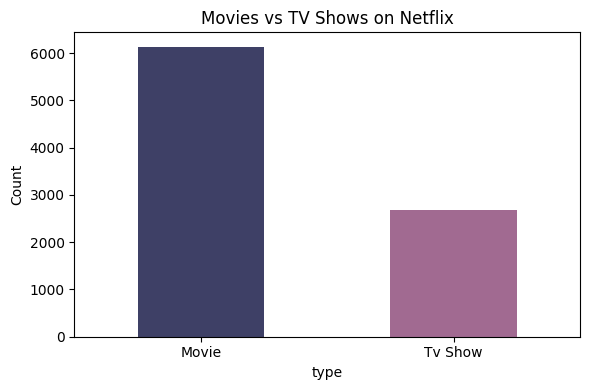

In [4]:
import os
#the split between Movies and TV Shows

type_counts = df['type'].value_counts()

plt.figure(figsize=(6,4))
type_counts.plot(kind='bar', color=['#3e4066', '#a16a91'])
plt.title('Movies vs TV Shows on Netflix')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.tight_layout()

# Create the 'charts' directory if it doesn't exist
os.makedirs('charts', exist_ok=True)

plt.savefig('charts/01_type_split.png')
plt.show()

OBSERVATION:- THERE ARE MORE MOVIES THAN TV SHOWS ON NETFLIX (MORE THAN ABOUT 2x MORE)


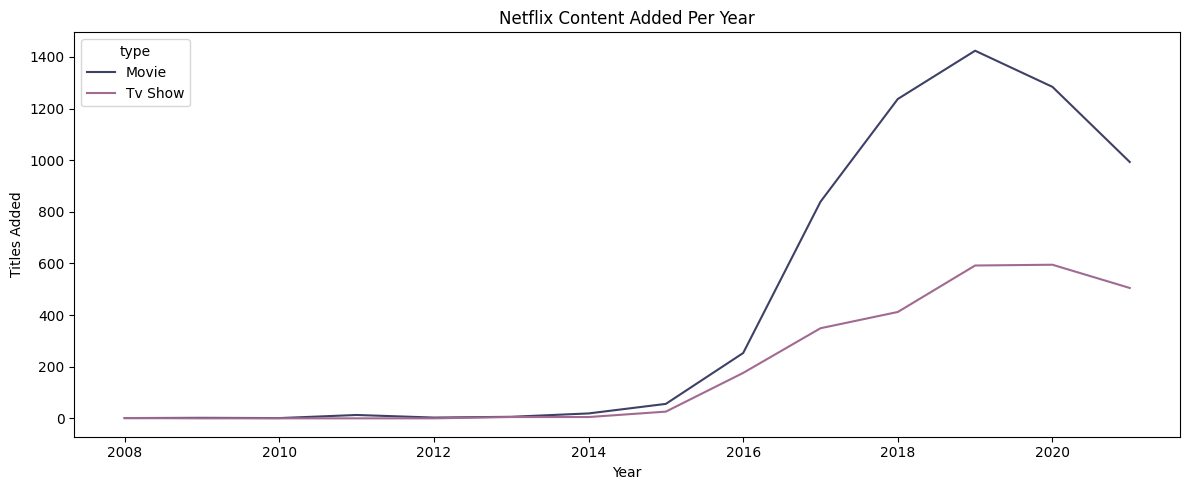

In [5]:
#Netflix library's growth over the years.

growth = df.groupby(['year_added', 'type']).size().unstack(fill_value=0)

growth.plot(figsize=(12,5), color=['#3e4066', '#a16a91'])
plt.title('Netflix Content Added Per Year')
plt.xlabel('Year')
plt.ylabel('Titles Added')
plt.tight_layout()
plt.show()

Observation: Netflix's explosion around 2016–2019

/tmp/ipykernel_3480/2273309193.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_countries.values, y=top_countries.index, palette='magma')


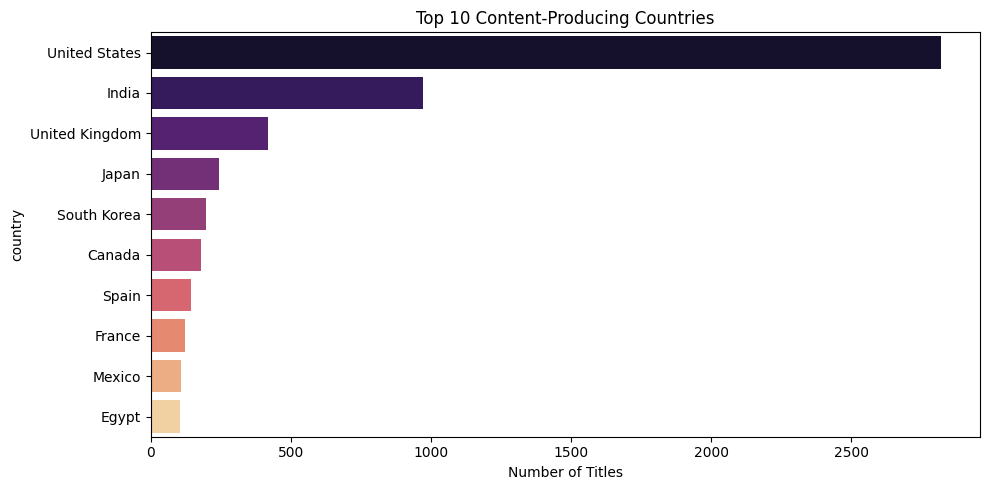

In [6]:
#Which countries produce the most content?

top_countries = df[df['country'] != 'Unknown']['country'].value_counts().head(10)

plt.figure(figsize=(10,5))
sns.barplot(x=top_countries.values, y=top_countries.index, palette='magma')
plt.title('Top 10 Content-Producing Countries')
plt.xlabel('Number of Titles')
plt.tight_layout()
plt.show()

/tmp/ipykernel_3480/2701762247.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='rating', order=rating_order, palette='magma')


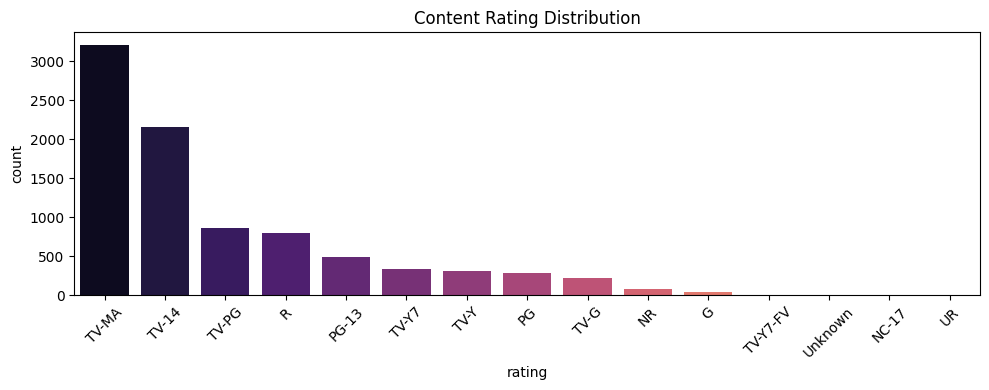

In [7]:
# rating distribution

rating_order = df['rating'].value_counts().index

plt.figure(figsize=(10,4))
sns.countplot(data=df, x='rating', order=rating_order, palette='magma')
plt.title('Content Rating Distribution')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

/tmp/ipykernel_3480/2251743416.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=list(counts), y=list(genres), palette='Reds_r')


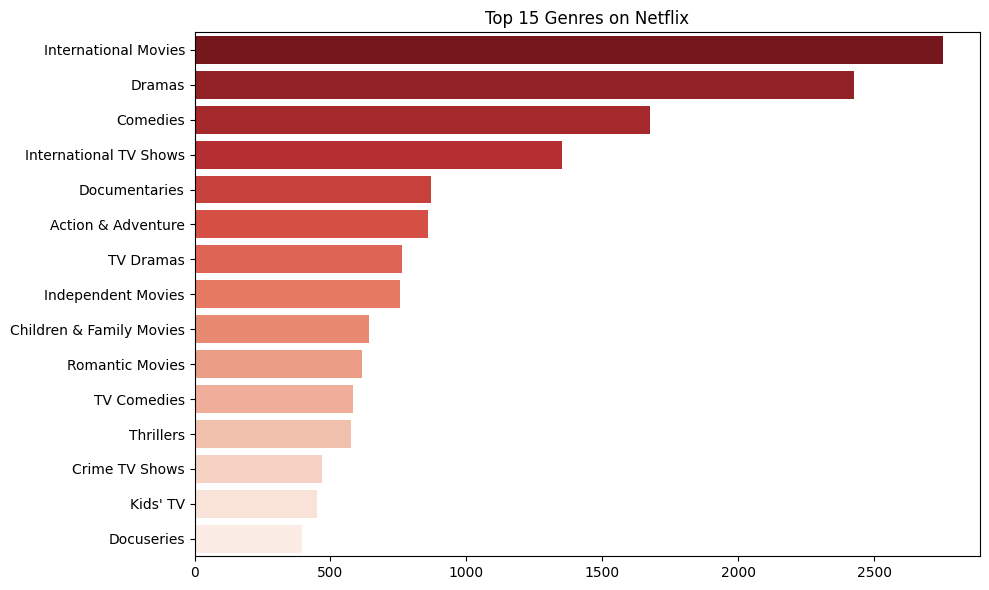

In [8]:
#the most common genres

from collections import Counter

all_genres = df['listed_in'].str.split(',').explode().str.strip()
genre_counts = Counter(all_genres).most_common(15)

genres, counts = zip(*genre_counts)
plt.figure(figsize=(10,6))
sns.barplot(x=list(counts), y=list(genres), palette='Reds_r')
plt.title('Top 15 Genres on Netflix')
plt.tight_layout()
plt.show()

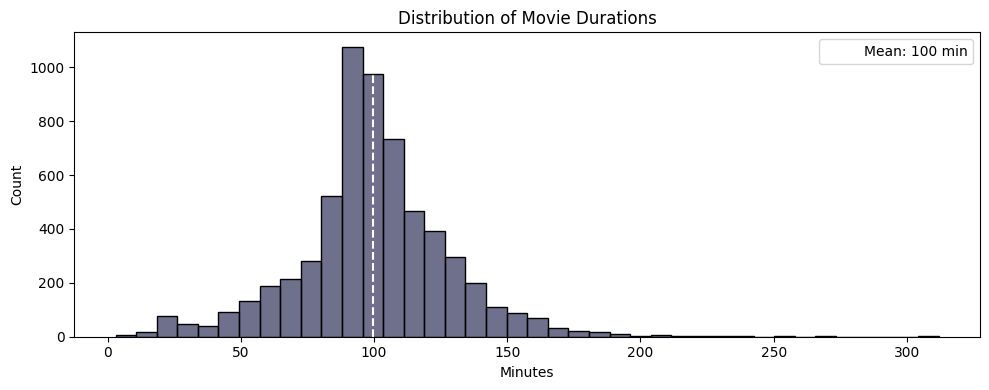

In [9]:
# length of Netflix movies on average

movies = df[df['type'] == 'Movie'].dropna(subset=['duration_minutes'])

plt.figure(figsize=(10,4))
sns.histplot(movies['duration_minutes'], bins=40, color='#3e4066')
plt.axvline(movies['duration_minutes'].mean(), color='white', linestyle='--', label=f"Mean: {movies['duration_minutes'].mean():.0f} min")
plt.title('Distribution of Movie Durations')
plt.xlabel('Minutes')
plt.legend()
plt.tight_layout()
plt.show()

NEXT STEP: converting text/categories into numbers that a ML model can learn from.
